# S&P 500 Options: Tabular Deep Learning

Gradient boosting has been the default answer for tabular data for a decade, and neural networks
have repeatedly failed to beat it there. TabM is one of the architectures built to close that
gap, and it gets an ensemble's benefit without an ensemble's cost.

Every member shares one two-layer network, so the features are transformed once. What separates
the members is applied after that: each owns a vector, the same length as the shared layer's
output, that multiplies those activations element by element, and its own final linear layer
mapping the scaled activations to a prediction. The vectors are randomly initialised and trained,
so each member reads a differently emphasised view of the same representation and reaches a
different answer; the model's prediction is their mean. Disagreement between members is where an
ensemble's benefit comes from, and here it is bought with one vector and one output layer per
member rather than a whole additional network.

This notebook fits the three declared TabM sizes on the short-straddle return and publishes a
prediction set for every training epoch the configuration checkpoints at. The epoch is part of
the model's identity, exactly as the boosting iteration is in
[`07_gbm`](07_gbm.ipynb): a network at epoch 50 and the same network at epoch 200 are two
candidates, not one candidate observed twice.

**Learning objectives**

- Fit an ensembling neural architecture on the same panel the linear and boosting notebooks used,
  so that the comparison is between model families and not between inputs.
- Publish every checkpoint as its own candidate rather than keeping the epoch that scored best,
  and say why keeping one would be a selection.
- Pin the compute device the population was fitted on, because it is part of what the training
  identity is computed from.

**Book reference**: Chapter 12 (Deep Learning for Trading).

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices, and
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run per configuration and one complete validation prediction set
per checkpoint, grouped under a named population that
[`11_model_analysis`](11_model_analysis.ipynb) and [`12_backtest`](12_backtest.ipynb) resolve by
name. Selection happens in `12_backtest`, on validation backtest Sharpe. The information
coefficient shown here is a diagnostic and decides nothing.

In [1]:
"""Fit the declared S&P 500 options tabular deep-learning population."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    resolved_model_plan,
    run_model_population,
    supersedes_for_run,
)
from case_studies.sp500_options.research_workflow import (
    declared_dl_device,
    published_dl_device,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = "4b8eaa6991ec"
DEVICE: str = ""

In [4]:
study = open_study("sp500_options", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

The label set comes from the study's own declaration rather than from a constant in this
notebook. `config/setup.yaml` says which labels the sweep fits, and each label's menu at
`config/training/{label}.yaml` says what to fit for it; `declared_labels` is the intersection.
That distinction matters here more than anywhere else in the repository: this case study keeps
full training menus for four fixed-horizon labels that `02_labels` writes for other notebooks to
read and that the sweep dropped, and each of those four declares the same three TabM sizes. A
notebook holding its own copy of the label list would agree with the declaration until someone
changed one of them, and then fit a different population without saying so.

In [5]:
labels = tuple(LABELS) or declared_labels(study, "tabular_dl")
configs = load_model_configs(
    study,
    "tabular_dl",
    labels=labels,
    config_names=CONFIG_NAMES or None,
)
# `model_class` is empty for every row: the TabM presets under `case_studies/config/tabm/`
# declare their architecture in `params` and carry no `model_class` key, the way the LightGBM
# presets do not either. Showing the column would put a blank field in front of the reader.
configs.drop("model_class")

family,label,config_name,params
str,str,str,str
"""tabular_dl""","""ret_to_expiry""","""tabm_s""","""dropout=0.1, hidden_dim=64, n_…"
"""tabular_dl""","""ret_to_expiry""","""tabm_l""","""dropout=0.1, hidden_dim=256, n…"
"""tabular_dl""","""ret_to_expiry""","""tabm_m""","""dropout=0.1, hidden_dim=128, n…"


The three configurations differ on one axis, capacity, in two places at once: the width of each
hidden layer and the number of ensemble members sharing the backbone. `tabm_s` is 64 units wide
with 4 members, `tabm_m` doubles both, and `tabm_l` doubles them again. Dropout, batch size,
training length and the checkpoint interval are identical across the three, so what separates
them is how much the model can represent and how many disagreeing views it averages, and not how
long or how hard it was trained.

`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name. The comparison is over `(label, config_name)` pairs
rather than over a count, because the four out-of-sweep menus each declare exactly these three
configurations - so a narrowed run can match the canonical population on size while sharing none
of its members.

The device is checked in the same cell. A network trained on a GPU and the same network trained
on a CPU accumulate their sums in different orders and reach different weights, so the device is
part of what the fitted model is and is recorded inside the computation's identity rather than
beside it. The device this population was fitted on is declared once, in `modeling.dl.device` in
`config/setup.yaml`, and read from there by all four deep-learning notebooks rather than retyped
in each. On a machine with no NVIDIA card the run therefore stops at the next cell rather than
quietly training something else: set `DEVICE="cpu"` and pass a `POPULATION_NAME` to fit the same
grid there, under its own name.

In [6]:
published_device = published_dl_device()
device = declared_dl_device(DEVICE)
print(f"training device: {device} (declared: {published_device})")

if (
    narrows_declared_catalog(study, "tabular_dl", configs) or device != published_device
) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not the complete declared catalog on {published_device!r}, so it cannot "
        f"publish the canonical population; pass POPULATION_NAME to give it its own"
    )

training device: cuda (declared: cuda)


## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and fixes the checkpoint schedule. Nothing is fitted yet, so the plan
can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row**, so the
  three sizes are being measured on the same sample as each other and as the linear and boosting
  notebooks.
- **`folds` is the same everywhere** and equals the number of walk-forward splits `05_evaluation`
  established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is the number of training states each configuration will publish predictions
  for.** Multiply it by the number of rows to get how many candidate models this notebook is
  about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
    "checkpoints",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end,checkpoints
str,i64,i64,i64,i64,date,date,i64
"""tabm_l""",52,540,135709,2,2019-01-07,2020-11-25,8
"""tabm_m""",52,540,135709,2,2019-01-07,2020-11-25,8
"""tabm_s""",52,540,135709,2,2019-01-07,2020-11-25,8


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one imputes and standardizes the features on the training rows alone, trains the network for
the declared number of epochs, and at each checkpoint epoch predicts that fold's validation rows
with the weights as they stand. The per-fold predictions are concatenated into one series
covering the whole validation period, one series per checkpoint.

**Every checkpoint becomes its own registered prediction set.** Keeping only the epoch whose
information coefficient came out highest would be a choice made on validation data and then
reported as if the training procedure had produced it, which is the same error as reporting the
best of a hyperparameter search as a single experiment. The stopping point is a free parameter
like any other, so it is carried into the comparison and paid for there.

`SUPERSEDES_POPULATION` names an earlier snapshot this run replaces. It is empty because this
population has no predecessor; a re-fit under a corrected parameter would set it, and the value
is part of what the population is hashed over.

In [8]:
population_name = POPULATION_NAME or "sp500-options-tabular-dl-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=supersedes_for_run(
        study,
        population_name=population_name,
        declared=SUPERSEDES_POPULATION or None,
        execution_tier=EXECUTION_TIER,
    ),
)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

Preparing and releasing folds...


  Fold 0: train=145,923  val=58,767


      epoch  25/200: loss=0.558395, IC=+0.0034


      epoch  50/200: loss=0.538961, IC=+0.0081


      epoch  75/200: loss=0.526538, IC=+0.0082


...

      epoch 200/200: loss=0.469446, IC=-0.0041


    Fold 1: best_ep=100, IC=-0.0025 (52.0s)


    → best_epoch=200, IC=+0.0082 (107.0s)



  Best: a8b2090e3d00 @ epoch 200 (IC=+0.0082)


3 configurations fitted
population sp500-options-tabular-dl-validation-v1: 24 prediction sets


## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the positions by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period. It describes the predictions; it selects nothing, here or downstream.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("config_name", "checkpoint_value")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("tabular execution returned a partial checkpoint")
catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)
if catalog.get_column("label").n_unique() > 1:
    raise NotImplementedError(
        "this notebook charts one label; facet the figure before adding a sweep variant"
    )
print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select("config_name", "checkpoint_value", "ic_mean", "ic_std", "ic_n_days", "full_coverage")

24 candidate models: 3 configurations
at 8 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,i64,f64,f64,f64,bool
"""tabm_l""",25,-0.007034,0.005814,478.0,true
"""tabm_l""",50,-0.006308,0.004932,478.0,true
"""tabm_l""",75,0.000636,0.005541,478.0,true
"""tabm_l""",100,0.003303,0.008378,478.0,true
"""tabm_l""",125,0.003004,0.006605,478.0,true
…,…,…,…,…,…
"""tabm_s""",100,0.000561,0.007569,478.0,true
"""tabm_s""",125,0.000251,0.007131,478.0,true
"""tabm_s""",150,0.001119,0.006999,478.0,true


### What more training does

Each line traces one configuration's out-of-sample information coefficient as training proceeds.
This is the figure the checkpoint dimension exists to produce, and it separates two things that a
single end-of-training number cannot.

A line that rises and then falls has an interior optimum: the network was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
around zero without trend never had anything to learn, and its highest point is wherever the
noise happened to peak. Both produce a respectable-looking maximum, which is why the maximum is
not what gets carried forward.

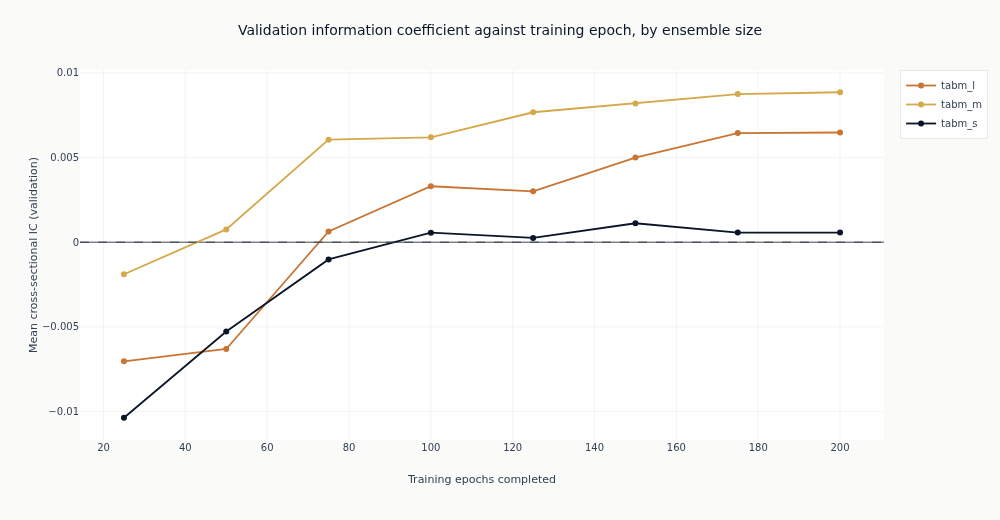

In [10]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
sizes = {"tabm_s": COLORS["blue"], "tabm_m": COLORS["amber"], "tabm_l": COLORS["copper"]}
fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines+markers",
            name=config_name,
            line=dict(color=sizes.get(config_name, COLORS["neutral"]), width=1.8),
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation information coefficient against training epoch, by ensemble size",
    height=520,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=10)),
)
fig_curves.update_xaxes(title_text="Training epochs completed")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean cross-sectional validation information coefficient against training "
    "epoch, one line per declared TabM ensemble size.",
)

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_options", workspace="~/ml4t-experiments")
configs = load_model_configs(study, "tabular_dl", config_names=["tabm_s"])
requests = model_requests(study, configs, overrides={"device": "cuda"})
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-tabm-v1")
```

To fit something new, add a preset at `case_studies/config/tabm/tabm_xl.yaml` and list `tabm_xl`
under `tabular_dl:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one rather than replacing it.

## Key takeaways

- A checkpoint is part of a model's identity. Publishing every one and letting the downstream
  backtest choose keeps the cost of that choice inside the comparison, where it can be accounted
  for, instead of hiding it in a number reported as a single experiment.
- Anything that enters the identity is pinned rather than discovered. The compute device is the
  example here: reading it off the hardware present would give the same notebook different
  identities on different machines.
- The label set has one home. A notebook that restates it agrees with the declaration until the
  declaration moves, and then fits a different population silently.

**Known limitations**: three sizes on one axis is a demonstration of how capacity is varied, not
a search over TabM's hyperparameters, and dropout, learning rate and depth are held at the
preset's values throughout. The information coefficient shown is pooled across folds and carries
no interval here; `11_model_analysis` is where the predictions are compared with uncertainty.